<a href="https://colab.research.google.com/github/vestrada-data/Project_NovaRetail/blob/main/Project_NovaRetail_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv('novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head(5)


,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:

- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `ingreso_anual`
- `satisfaccion`


La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `satisfaccion` debería tener valores enteros.

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
df['satisfaccion'] = df['satisfaccion'].astype(int)


In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  int64  
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
df[['edad','nivel_ingreso','visitas_mes','compras_mes','gasto_publicidad_dirigida',
    'ingreso_anual', 'satisfaccion']].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,ingreso_anual,satisfaccion
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,36.594180,3.160067
std,11.492378,9833.166305,3.158189,1.105284,10.880724,34.484888,0.753978
min,18.000000,8000.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,0.000000,3.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,30.705000,3.000000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,58.220000,4.000000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,244.690000,5.000000


✍️ **Comentario**:
Diagnóstico inicial de variables numéricas

- `edad` - Presenta una distribución equilibrada con una media de 38 años y un rango que abarca desde los 18 hasta los 75 años. La mediana (50%) es de 38, lo que sugiere una distribución simétrica sin sesgos aparentes hacia grupos jóvenes o mayores.
- `nivel_ingreso` - Muestra una dispersión considerable con una desviación estándar de 9,833. Existe una brecha amplia entre el valor mínimo (8,000) y el máximo (74,790), lo que podría indicar la presencia de diferentes segmentos socioeconómicos en la muestra.
- `visitas_mes`- Es una de las variables más estables, con un promedio de 10 visitas y una desviación estándar baja (3.15).
 El valor máximo de 25 visitas indica que hay usuarios "heavy users" que casi triplican la actividad del usuario promedio.
- `compras_mes` - Refleja una baja tasa de conversión, con una media de apenas 1.20 compras.
  El 25% de los datos es 0, lo que confirma que una cuarta parte de la base de datos no realiza transacciones a pesar de las visitas.
- `gasto_publicidad_dirigida`- Tiene un rango de acción que va desde 0 hasta 75.51. La media (20.14) es muy cercana al valor del 50% (19.73), lo que indica un gasto publicitario muy consistente en la parte central de la muestra.
- `ingreso_anual`-Presenta una anomalía de datos, ya que tanto el mínimo como el percentil del 25% son 0, sugiriendo una gran cantidad de registros sin información o usuarios sin ingresos reportados.
- `satisfaccion`- Se mueve en un rango estrecho de 1 a 5, con una media de 3.16. La mayoría de los usuarios se encuentran en un estado de satisfacción neutral o positiva, dado que el 75% de los datos tiene un puntaje de 4 o inferior.

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
print(f"Valores únicos en miembro_premium: {df['miembro_premium'].nunique()}")
print(f"Tipos de valores en miembro_premium: {df['miembro_premium'].unique()}")
print(f"Valores de abandono: {df['abandono'].nunique()}")
print(f"Tipos de valores de abandono: {df['abandono'].unique()}")

Valores únicos en miembro_premium: 2
Tipos de valores en miembro_premium: [0 1]
Valores de abandono: 2
Tipos de valores de abandono: [0 1]


✍️ **Comentario**:

Diagnóstico inicial de variables binarias

- `miembro_premium` —Es una variable booleana que clasifica a los usuarios según su nivel de suscripción.
Este dato es clave para entender si el comportamiento de "muchas visitas y pocas compras" cambia drásticamente entre usuarios estándar (0) y premium (1). Ideal para la segmentación.
- `abandono` — Es la variable objetivo (target) que indica si un cliente dejó de usar el servicio o se mantiene activo.
Es la variable más crítica. Debemos observar si existe una correlación negativa fuerte con satisfaccion o una correlación positiva con la falta de compras_mes.

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
print(f"Valores únicos en tipos de dispositivos: {df['tipo_dispositivo'].nunique()}")
print(f"Tipos de dispositivos: {df['tipo_dispositivo'].unique()}")
print(f"Valores únicos en regiones: {df['region'].nunique()}")
print(f"Regioses: {df['region'].unique()}")



Valores únicos en tipos de dispositivos: 3
Tipos de dispositivos: ['móvil' 'tablet' 'escritorio']
Valores únicos en regiones: 4
Regioses: ['norte' 'sur' 'este' 'oeste']


In [ ]:
# Explorar variables categóricas y cómo se distribuyen
df[['tipo_dispositivo','region']].describe()


,tipo_dispositivo,region
count,15000,15000
unique,3,4
top,móvil,norte
freq,9818,4395


✍️ **Comentario**:
Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — Existen 3 categorías únicas de dispositivos. El dispositivo "móvil" es el predominante, apareciendo en 9,818 de los 15,000 registros. Aproximadamente el 65%, lo cual es vital para correlacionar con la variable de satisfaccion.

- `region` - Se observa que hay  4 regiones geográficas distintas y la región "norte" es la más frecuente con 4,395 menciones. Al ser la zona con mayor volumen de usuarios, será el punto de referencia principal para comparar si el nivel_ingreso o el abandono varían significativamente según la ubicación geográfica.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

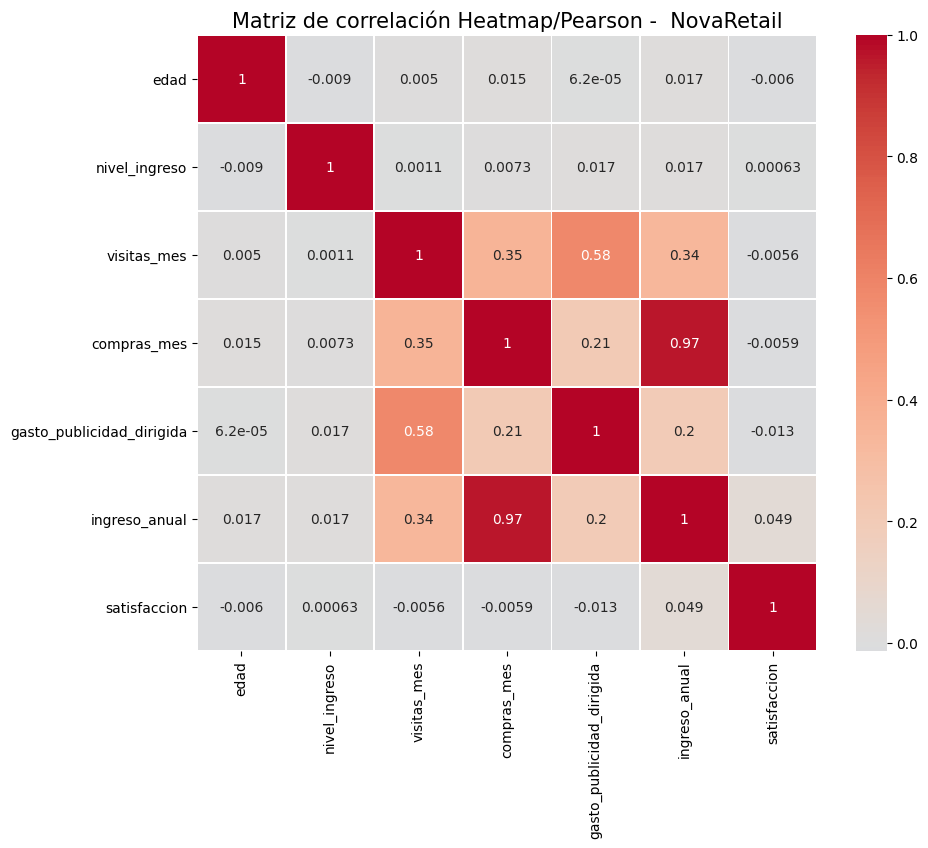

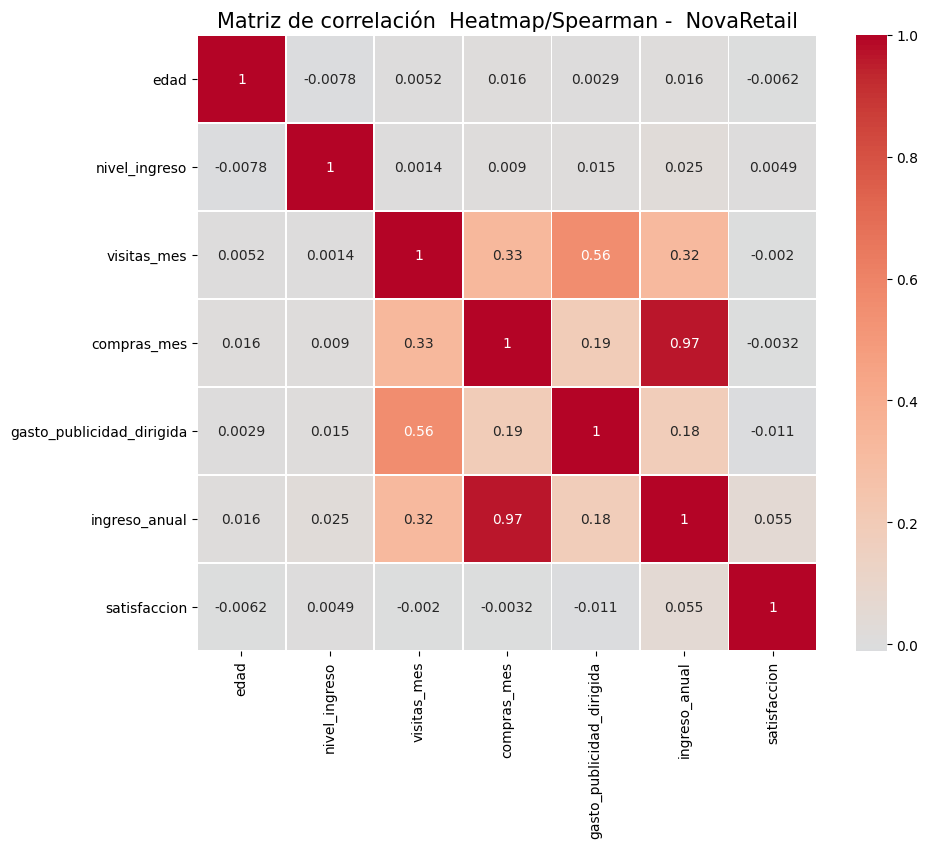

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
cols=['edad','nivel_ingreso','visitas_mes','compras_mes','gasto_publicidad_dirigida','ingreso_anual', 'satisfaccion']
def corr_num(df, colums,metodo):
   return df[cols].corr(method=metodo)

corr_pearson=corr_num(df,cols,'pearson')
plt.figure(figsize=(10,8))
sns.heatmap(corr_pearson,annot=True,cmap='coolwarm',center=0,linewidths=0.5)
plt.title ('Matriz de correlación Heatmap/Pearson -  NovaRetail',fontsize=15)
plt.show ()


corr_pearson=corr_num(df,cols,'spearman')
plt.figure(figsize=(10,8))
sns.heatmap(corr_pearson,annot=True,cmap='coolwarm',center=0,linewidths=0.5)
plt.title ('Matriz de correlación  Heatmap/Spearman -  NovaRetail',fontsize=15)
plt.show ()




✍️ **Comentario**:

Observaciones generales (Heatmap)  
   Se observa que:

  **Clúster 1 — Comportamiento de compra / actividad económica:** <br>
    compras_mes — ingreso_anual — visitas_mes — gasto_publicidad_dirigida (relaciones positivas)
- *visitas_mes* ↔ *gasto_publicidad_dirigida* (0.58) — correlación moderada-alta. A más visitas mensuales, mayor gasto en publicidad dirigida asociado a ese cliente.
- *visitas_mes* ↔ compras_mes (0.35) — relación moderada esperada: más visitas se asocian con más compras, aunque no de forma muy estrecha.
- visita_mes ↔ ingreso anual (0.34) - relación moderada: más visitas se asocian a un incremento en el ingreso anual.
- *gasto_publicidad_dirigida ↔ compras_mes (0.21) y ↔ ingreso_anual (0.20)* — relaciones débiles.

 **Clúster 2 — Variables independientes:** <br>
edad — nivel_ingreso — satisfaccion
- *satisfaccion* - Su mayor valor es 0.049 con ingreso_anual. Siendo independiente de todo (incluso de compras o visitas) es un hallazgo relevante para estrategia, la frecuencia de compra no explica la satisfacción del cliente.
- *satisfaccion, edad y nivel_ingreso* con valores cercanos a cero en todas las direcciones.

  
- No hay correlaciones negativas significativas.

Observaciones respecto a *ingreso_anual*
- Presenta la relación positiva más fuerte de toda la matriz con *compras_mes* (0.97). Quienes compran más veces al mes tienden a tener mayor ingreso anual registrado.

### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.
    
1. Confirmó correlaciones del heatmap visualmente
2. Descartó patrones no lineales ocultos
3. Identificó variables que necesitan métodos distintos (miembro premium y abandono)
4. edad, nivel_ingreso, visitas_mes:Las tres muestran nubes completamente amorfas entre sí — sin estructura lineal ni no-lineal visible.
5. nivel_ingreso tiene distribución amplia y uniforme
4. No hay efecto en U ni clusters ocultos — El heatmap era confiable.

- **Si decides no incluirlo**:
  - Explica por qué.
  

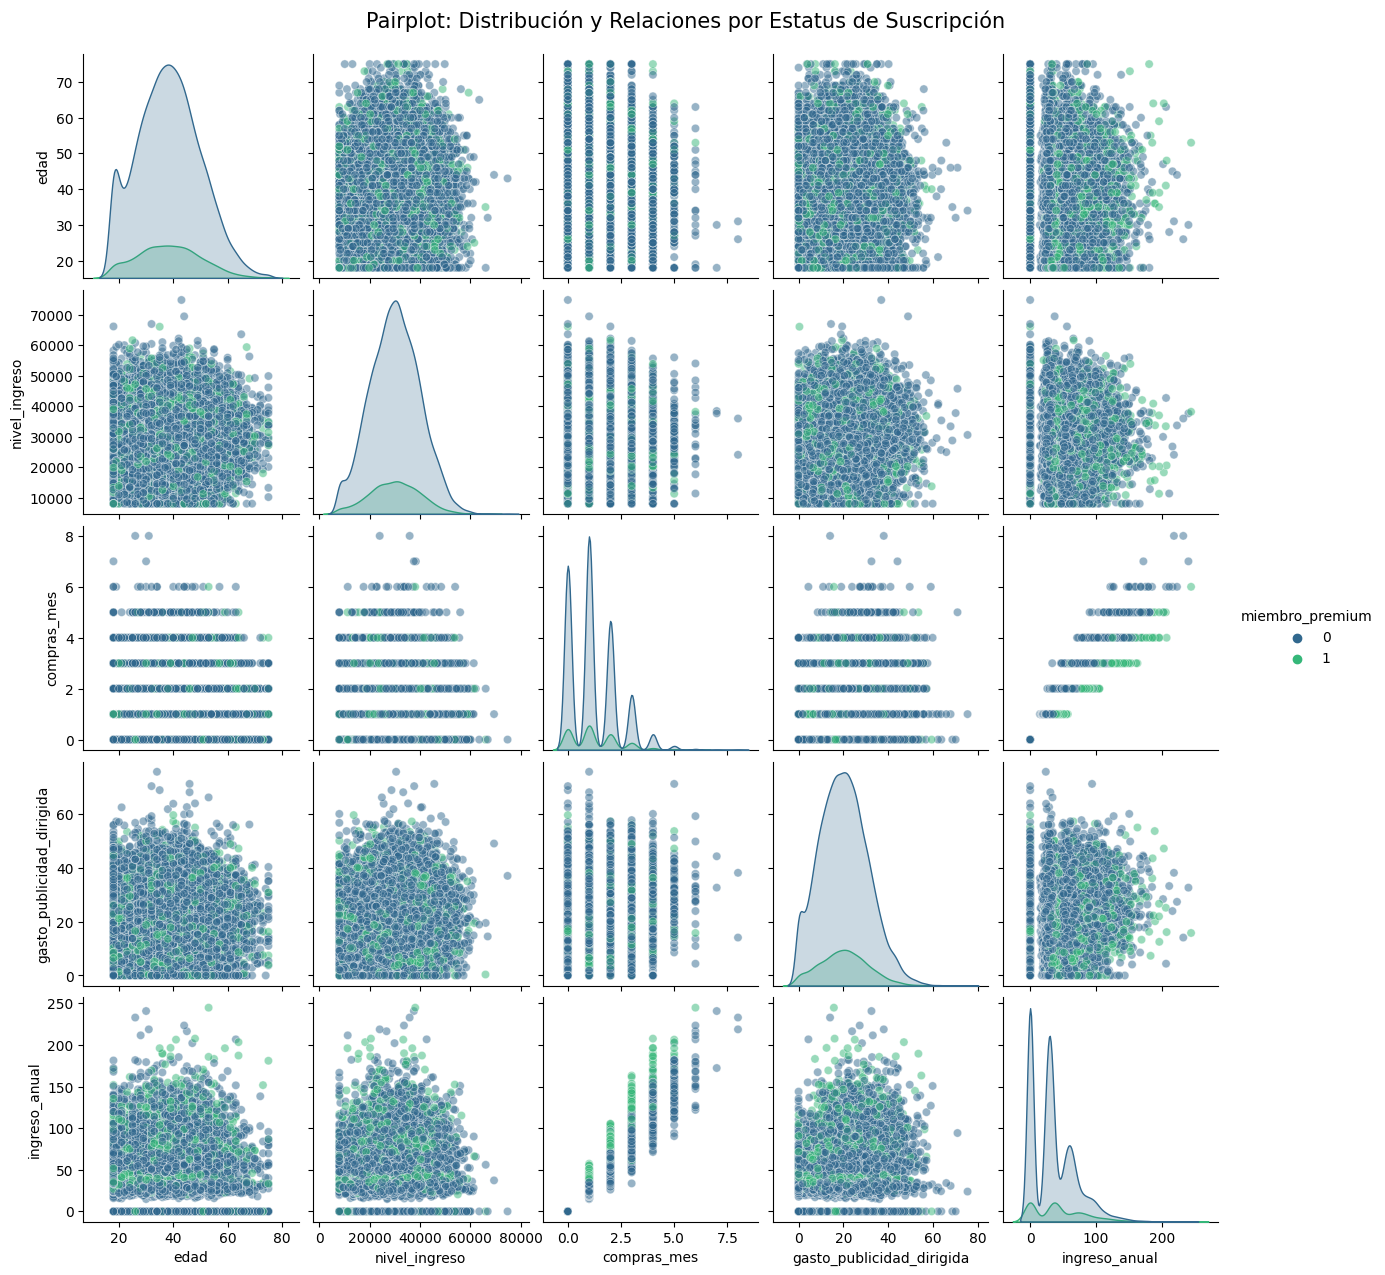

In [ ]:

# Scatterplot General (Pairplot)
# Visualizamos una muestra para optimizar el rendimiento y detectar agrupamientos por suscripción
sns.pairplot(df,
             vars=['edad', 'nivel_ingreso', 'compras_mes', 'gasto_publicidad_dirigida', 'ingreso_anual'],
             hue='miembro_premium',
             palette='viridis',
             plot_kws={'alpha': 0.5})
plt.suptitle("Pairplot: Distribución y Relaciones por Estatus de Suscripción", y=1.02, fontsize=15)
plt.show()

### Scatterplot para pares clave

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes

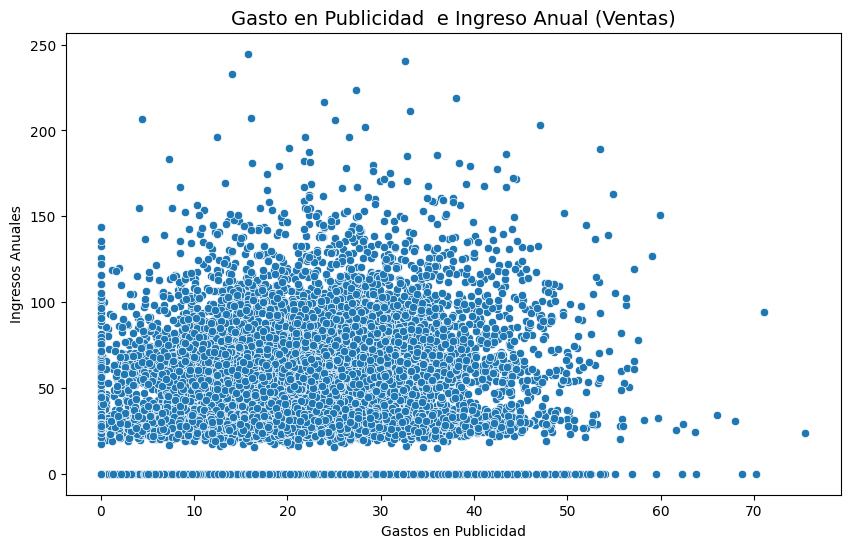

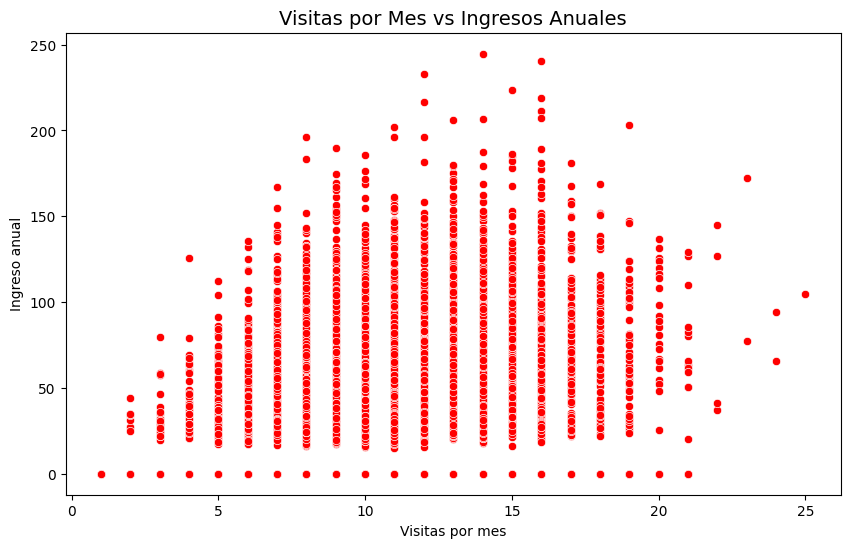

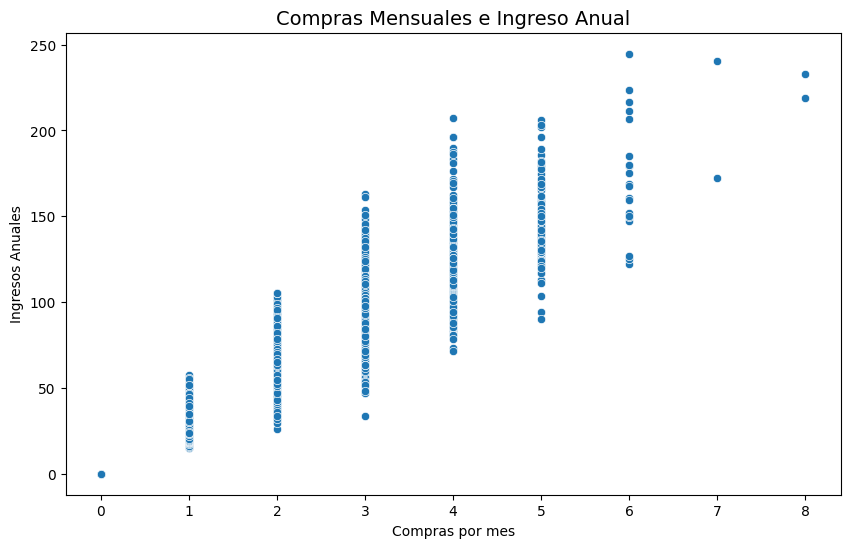

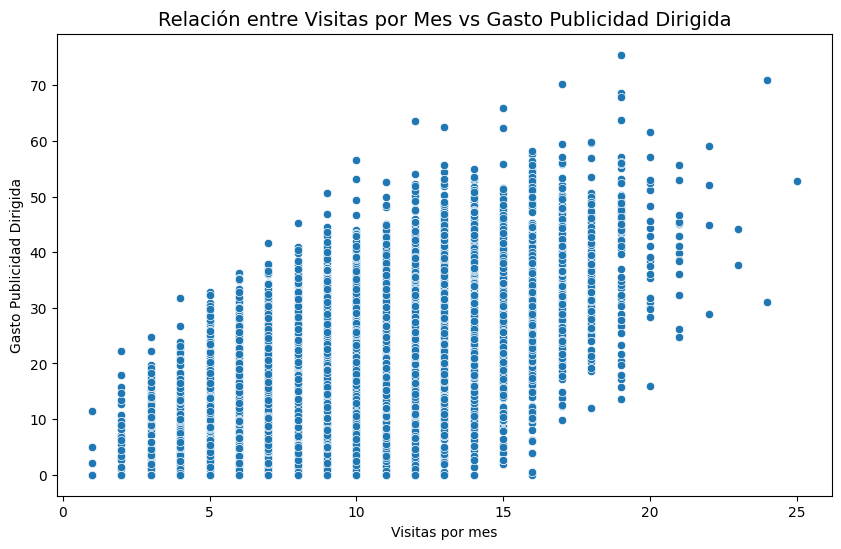

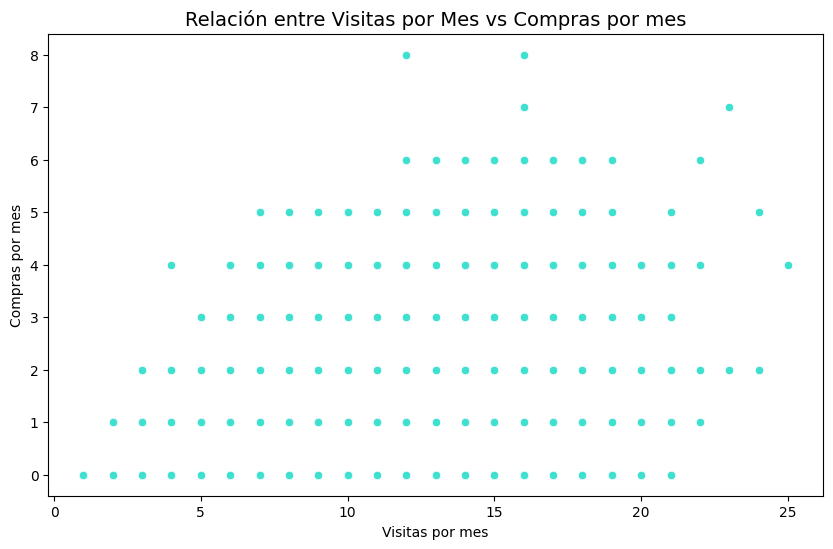

In [ ]:
# Analizamos la relación entre Gasto en Publicidad e Ingreso Anual (Ventas)

#Scatterplot Compras_mes vs Ingresoo_anual (0.18)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='gasto_publicidad_dirigida', y='ingreso_anual')
plt.title('Gasto en Publicidad  e Ingreso Anual (Ventas)', fontsize=14)
plt.xlabel('Gastos en Publicidad')
plt.ylabel('Ingresos Anuales')
plt.show()

#Scatterplot visita_mes  vs  ingresos_anuales  (0.34)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='visitas_mes', y='ingreso_anual', color='red')
plt.title('Visitas por Mes vs Ingresos Anuales', fontsize=14)
plt.xlabel('Visitas por mes')
plt.ylabel('Ingreso anual')
plt.show()

#Scatterplot Compras_mes vs Ingreso_anual (0.97)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual')
plt.title('Compras Mensuales e Ingreso Anual', fontsize=14)
plt.xlabel('Compras por mes')
plt.ylabel('Ingresos Anuales')
plt.show()

#Scatterplot visita_mes  vs  gasto_publicidad_dirigida (0.58)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='visitas_mes', y='gasto_publicidad_dirigida')
plt.title('Relación entre Visitas por Mes vs Gasto Publicidad Dirigida', fontsize=14)
plt.xlabel('Visitas por mes')
plt.ylabel('Gasto Publicidad Dirigida')
plt.show()

#Scatterplot visita_mes  vs  compras_mes  (0.35)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='visitas_mes', y='compras_mes', color='turquoise')
plt.title('Relación entre Visitas por Mes vs Compras por mes', fontsize=14)
plt.xlabel('Visitas por mes')
plt.ylabel('Compras por mes')
plt.show()




✍️ **Comentario**:

Observaciones iniciales (Scatterplot)

**gasto_publicidad_dirigida vs ingreso_anual**
- Dirección: sin dirección
- Dispersión:La dispersión es extremadamente alta. Los puntos forman un bloque ancho y masivo sin un patrón claro.
- Colinealidad nula.

**compras_mes vs ingreso_anual**
- Dirección positiva. A medida que aumentan las compras por mes, el ingreso anual sube de forma consistente. La tendencia es claramente ascendente.
- La dispersión es baja y estable. Dentro de cada grupo de compras, los ingresos no varían mucho. Los clientes que compran igual tienden a ganar parecido.
- No hay presencia de outliers. Todos los valores respetan la estructura escalonada.
- Posibilidad de colinealidad muy alta, si conoces compras_mes, puedes predecir ingreso_anual con alta precisión.
  Hipótesis: Ambas variables vienen de la misma fuente o tabla y hay redundancia en el diseño del dataset

**visitas_mes vs ingreso_anual**
- Dirección: Positiva débil.
- Con alta dispersión. Esto indica la presencia de usuarios con un alto número de visitas que no concretan compras, lo que impide que la relación sea sólida.
- No hay colinealidad.
-
**visitas_mes vs gasto_publicidad_dirigido**
- Presenta una dirección positiva, conforme aumentan las visitas en el mes, el gasto de publicidad dirigida se incrementa.
- Dispersión: Alta y creciente. Las columnas de la izquierda son cortas y compactas. Las de la derecha son largas y abiertas. Es decir:Los clientes con pocas visitas tienen gastos predecibles y similares entre sí. Los clientes con muchas visitas tienen gastos muy variables — algunos gastan poco, otros muchísimo.
- Hay outliers. Puntos aislados en la parte superior del gráfico que se separan del resto de su columna.
Colinealidad moderada. Con y el solapamiento visible entre columnas, estas dos variables pueden coexistir en un modelo.

**visitas_mes vs compras_mes**
- Esta relación tiene una dirección positiva débil. Hay una tendencia leve hacia arriba.
- Su dispersión es alta y uniforme. Dentro de cada columna los puntos se distribuyen por todo el rango vertical.
- Se observan algunos outliers aislados, nada grave.
- Colinealidad inexistente.  El solapamiento total entre columnas confirma que estas variables son esencialmente independientes.



## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes

# inreso_anual vs gasto_publicidad_dirigida
corr_pearson0=df['ingreso_anual'].corr(df['gasto_publicidad_dirigida'], method='pearson')
corr_spearman0=df['ingreso_anual'].corr(df['gasto_publicidad_dirigida'], method='spearman')
print(f"Coeficiente de Pearson (Ingreso Anual vs Gasto de publicidad): {corr_pearson0:.3f}")
print(f"Coeficiente de Spearman (Ingreso Anual vs Gasto de publicidad): {corr_spearman0:.3f}")
print()

# inreso_anual vs compras_mes
corr_pearson=df['ingreso_anual'].corr(df['compras_mes'], method='pearson')
corr_spearman=df['ingreso_anual'].corr(df['compras_mes'], method='spearman')
print(f"Coeficiente de Pearson (Ingreso Anual vs Compras): {corr_pearson:.3f}")
print(f"Coeficiente de Spearman (Ingreso Anual vs Compras): {corr_spearman:.3f}")
print()
# gasto_publicida_dirigido vs visitas_mes
corr_pearson2=df['gasto_publicidad_dirigida'].corr(df['visitas_mes'], method='pearson')
corr_spearman2=df['gasto_publicidad_dirigida'].corr(df['visitas_mes'], method='spearman')
print(f"Coeficiente de Pearson (Gasto publicidad dirigida vs Visita mensuales): {corr_pearson2:.3f}")
print(f"Coeficiente de Spearman (Gasto publicidad dirigida vs Visita mensuales): {corr_spearman2:.3f}")



Coeficiente de Pearson (Ingreso Anual vs Gasto de publicidad): 0.197
Coeficiente de Spearman (Ingreso Anual vs Gasto de publicidad): 0.185

Coeficiente de Pearson (Ingreso Anual vs Compras): 0.967
Coeficiente de Spearman (Ingreso Anual vs Compras): 0.967

Coeficiente de Pearson (Gasto publicidad dirigida vs Visita mensuales): 0.579
Coeficiente de Spearman (Gasto publicidad dirigida vs Visita mensuales): 0.559


In [ ]:
# Calcular correlación entre variables relevantes
# compras_mes vs visitas_mes
corr_pearson3=df['compras_mes'].corr(df['visitas_mes'], method='pearson')
corr_spearman3=df['compras_mes'].corr(df['visitas_mes'], method='spearman')
print(f"Coeficiente de Pearson (Compras mensuales vs Visita mensuales): {corr_pearson3:.3f}")
print(f"Coeficiente de Spearman (Compras mensuales vs Visita mensuales): {corr_spearman3:.3f}")
print()
corr_pearson4=df['ingreso_anual'].corr(df['visitas_mes'], method='pearson')
corr_spearman4=df['ingreso_anual'].corr(df['visitas_mes'], method='spearman')
print(f"Coeficiente de Pearson (Ingreso Anual vs Visita mensuales): {corr_pearson4:.3f}")
print(f"Coeficiente de Spearman Ingreso Anual vs Visita mensuales): {corr_spearman4:.3f}")


Coeficiente de Pearson (Compras mensuales vs Visita mensuales): 0.354
Coeficiente de Spearman (Compras mensuales vs Visita mensuales): 0.333

Coeficiente de Pearson (Ingreso Anual vs Visita mensuales): 0.337
Coeficiente de Spearman Ingreso Anual vs Visita mensuales): 0.321


✍️ **Comentario**:
Observaciones de correlación
**inreso_anual vs gasto_publicidad_dirigida**
- Magnitud: 0.19 (Casi nula).
- Dirección: Casi inexistente.
- Colinealidad:inexistente

**ingreso_anual vs compras_mes**
- Magnitud: 0.967 (Muy fuerte).
- Dirección: Positiva. Existe una relación lineal directa; a medida que el ingreso aumenta, las compras aumentan en la misma proporción.
- Colinealidad: Riesgo Muy Alto. Un coeficiente superior a 0.90 sugiere que estas dos variables comparten casi la misma información.<br>
El hecho de que Pearson y Spearman sean idénticos indica que no hay outliers distorsionando esta relación; es una estructura de datos muy limpia y robusta.

**gasto_publicidad_dirigida vs visitas_mes**
- Magnitud: 0.579 (Moderada).
- Dirección: Positiva. El incremento en el presupuesto publicitario efectivamente está atrayendo más tráfico al sitio/tienda.
- Colinealidad: Baja/Nula. Al estar por debajo de 0.60, no representan un riesgo de redundancia. Son variables independientes que se complementan bien.<br>
Al ser una correlación moderada, significa que la publicidad explica una parte de las visitas, pero hay otros factores (como estacionalidad o marca) que también influyen.

**compras_mes vs visitas_mes**
- Magnitud: 0.354 (Débil).
- Dirección: Positiva.
- Colinealidad: Inexistente. Son variables claramente independientes.<br>
Tener más visitas no garantiza proporcionalmente más compras.

**ingreso_anual vs visitas_mes**
- Magnitud: 0.337 (Débil).
- Dirección: Positiva.
- Colinealidad: se confirma que no hay
El nivel de ingresos del usuario no es un determinante fuerte para la frecuencia con la que visita la plataforma. <br>Tanto personas con ingresos altos como bajos visitan el sitio de manera similar.

### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

def point_biserial(df, col_binaria, col_numerica):
   for col in col_numerica:
       pb,_=pointbiserialr(df[col_binaria],df[col])
       print(f'Correlación entre {col_binaria} y {col}')
       print(f'Punto biserial: {pb:.4f}')
       print()

col_num=['visitas_mes','compras_mes','gasto_publicidad_dirigida', 'ingreso_anual']

#Identificación de correlaciones con MIEMPBRO_PREMIUM
print ('CORRELACIÓN DE MIEMBROS PREMIUM')
point_biserial(df, 'abandono', col_num)

col_num2=['edad','nivel_ingreso','visitas_mes','compras_mes','gasto_publicidad_dirigida', 'ingreso_anual' ]

#Identificación de correlaciones con MIEMPBRO_PREMIUM
print ('CORRELACIÓN DE MIEMBROS PREMIUM')
point_biserial(df, 'miembro_premium', col_num2)



CORRELACIÓN DE MIEMBROS PREMIUM
Correlación entre abandono y visitas_mes
Punto biserial: -0.0089

Correlación entre abandono y compras_mes
Punto biserial: 0.0083

Correlación entre abandono y gasto_publicidad_dirigida
Punto biserial: -0.0046

Correlación entre abandono y ingreso_anual
Punto biserial: -0.0028

CORRELACIÓN DE MIEMBROS PREMIUM
Correlación entre miembro_premium y edad
Punto biserial: 0.0046

Correlación entre miembro_premium y nivel_ingreso
Punto biserial: -0.0056

Correlación entre miembro_premium y visitas_mes
Punto biserial: -0.0127

Correlación entre miembro_premium y compras_mes
Punto biserial: 0.0034

Correlación entre miembro_premium y gasto_publicidad_dirigida
Punto biserial: 0.0027

Correlación entre miembro_premium y ingreso_anual
Punto biserial: 0.0931



✍️ **Comentario**:
Observaciones Punto-biserial

**abandono vs visitas_mes**
- Magnitud: -0.0089 (Nula)
- Dirección: Negativa
- Diagnóstico: El volumen de visitas no influye en la retención. Los usuarios que entran 25 veces al mes tienen la misma probabilidad de irse que aquellos que entran solo 1 vez. No existe un patrón de "desconexión gradual" visible en los datos.

**abandono vs compras_mes**
- Magnitud: 0.0083 (Nula)
- Dirección: Positiva
- Diagnóstico:Se esperaría que a más compras, menor abandono. Sin embargo, el coeficiente indica que el hecho de haber comprado no genera lealtad ni predice la permanencia en este dataset.

**abandono vs gasto_publicidad_dirigida**
- Magnitud: -0.0046 (Nula)
- Dirección: Negativa
- Diagnóstico:La inversión en publicidad dirigida no está correlacionada con la retención. El esfuerzo de marketing para personalizar anuncios no está logrando reducir la tasa de abandono, ni tampoco la está provocando.

**miembro_premium vs edad**
- Magnitud: 0.0046 (Nula)
- Dirección: Positiva
- Diagnóstico: No existe un s generacional para la suscripción premium. La edad no es un factor determinante en la decisión de compra de la membresía.

**miembro_premium vs nivel_ingreso**
- Magnitud: -0.0056 (Nula)
- Dirección: Negativa
- Diagnóstico: El nivel de ingreso no está asociado con el estatus premium.  El programa premium parece ser accesible o atractivo para todos los estratos económicos por igual.

**miembro_premium vs visitas_mes**
- Magnitud: -0.0127 (Nula)
- Dirección: Negativa
- Diagnóstico:No hay diferencia en la frecuencia de visitas. De hecho, el signo negativo (aunque despreciable) sugiere que los premium visitan la plataforma ligerísimamente menos que los usuarios estándar.
  
**miembro_premium vs compras_mes** <br>
- Magnitud: 0.0034 (Nula)
- Dirección: Positiva
- Diagnóstico:Este es un punto crítico para el negocio. Ser miembro premium no influye en la cantidad de compras mensuales. Estadísticamente, un usuario premium compra lo mismo que uno que no lo es. El programa de membresía no está funcionando como un motor de ventas.

**miembro_premium vs gasto_publicidad_dirigida**
- Magnitud: 0.0027 (Nula)
- Dirección: Positiva
- Diagnóstico:No se está priorizando a los miembros premium con más publicidad, ni se está enfocando el gasto en convertir a los no-miembros. Existe una desconexión entre el marketing y el programa de lealtad.


### V de Cramér

In [ ]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency

def cramer_v(df, col1, col2):
    #tabla de contingencia
    tabla =pd.crosstab(df[col1] , df[col2])

    #calcular chi2
    chi2, p_value, dof, expected = chi2_contingency(tabla)

    #calcular el coeficiente V de Crámer
    n = tabla.values.sum()
    v = np.sqrt(chi2/(n*(min(tabla.shape)-1)))
    return v



In [ ]:
# Aplicar V de Cramér en variables relevantes

print ('Correlación aplicando V de Cramér en variables relevantes')
print()
# Satisfacción vs miembro_premium
v = cramer_v(df,'satisfaccion','miembro_premium')
print(f'Miembro Premium y Satisfacción: {v:.4f}')
print()
# tipo de dispositivo vs miembro_premium
v = cramer_v(df,'tipo_dispositivo','miembro_premium')
print(f'Miembro Premium y Tipo de dispositivo: {v:.4f}')
print()
# Regios vs Abandono del cliente
v = cramer_v(df,'region','abandono')
print(f'Abandono  y Región: {v:.4f}')
print()
# Tipo de dispositivo  vs abandono
v = cramer_v(df,'tipo_dispositivo','abandono')
print(f'Abandono y Tipo de dispositivo {v:.4f}')
print()




Correlación aplicando V de Cramér en variables relevantes

Miembro Premium y Satisfacción: 0.0250

Miembro Premium y Tipo de dispositivo: 0.0197

Abandono  y Región: 0.0154

Abandono y Tipo de dispositivo 0.0072



✍️ **Comentario**:
Observaciones V de Cramér

**miembro_premium vs satisfaccion (0.0250) y tipo_dispositivo (0.0197)**
- Magnitud: Nula.
- Diagnóstico: Sin importar el tipo de dispositivo, los clientes contratan la membresía por igual. Además, el hecho de pagar no garantiza que el usuario esté más satisfecho (ni viceversa).
- Diagnósitco: El valor del programa Premium no está ligado a una plataforma específica ni está generando una satisfacción superior en el cliente.

**abandono vs region (0.0154) y tipo_dispositivo (0.0072)**
- Magnitud: Prácticamente cero.
- Diagnósgico: El abandono no es un problema geográfico ni un problema por el tipo de dispositivo. Los clientes se van en la misma proporción en el Norte que en el Sur, y tanto si usan la app como la web.

## Sección 5 - Interpretación de resultados para el negocio


### Hallazgo 1 —  Ingreso Anual y el Comportamiento Transaccional

**Evidencia visual:**  Scatterplott y Heatmap

**Evidencia numérica:**  Pearson=0.97  Spearman:0.97

**Interpretación**  
En los datos se ve claramente que a mayor ingreso anual, mayor es el número de compras al mes.

**No podemos afirmar**  
Que tener más dinero sea una condición  directa para que un cliente compre más. <podría haber otro motivo oculto.

**Implicación de negocio**  
Significa que la cantidad de compras al mes es el reflejo  del dinero que tiene el cliente. Si un usuario no quiere indicar cuánto gana, el negocio puede identificar cuántas veces compra al mes para saber si es un cliente de ingresos altos o bajos, y así poder ofrecerle los productos adecuados.


### Hallazgo 2 — Causa de Abandono

**Evidencia numérica:**

*Puntos biseriales*<br>
abandono -visitas_mes: -0.0089 (nula)<br>
abandono -compras_mes l: 0.0083 (nula)<br>
abandono -gasto_publicidad_dirigida : -0.0046 (nula)<br>
abandono -ingreso_anual : -0.0028 (nula)<br>

*V de Cramér / Coeficiente Phi*<br>
Abandono  y Región: 0.0154 (nula)<br>
Abandono y Tipo de dispositivo: 0.007 (nula)<br>

**Interpretación**  
Los perfiles de los usuarios que abandonan la plataforma y los que permanecen en ella son estadísticamente indistinguibles en términos de volumen de transacciones, actividad de navegación, inversión publicitaria recibida, ubicación geográfica o canal tecnológico de acceso.

**No podemos afirmar**  
No podemos concluir si hay falta de interés en la publicidad o inconformidad con la app móvil solo porque las correlaciones son nulas. Tampoco se puede afirmar que el abandono sea un evento caótico, no tenemos las causas  capturadas en estas variables cuantitativas.

**Implicación de negocio**  
Se puede descartar que el abandono se deba a fallos específicos de la app en ciertos dispositivos o a problemas de logística/servicio en regiones particulares. El problema es sistémico.El disparador de la fuga probablemente se encuentra en factores cualitativos (atención al cliente, precios de la competencia, fallos de sistema).


### Hallazgo 3 — Evaluación del Programa Miembro Premium

**Evidencia visual:**  Heatmap

**Evidencia numérica:**  
*Puntos biseriales* <br>
miembro_premium y edad: 0.0046 (nula)<br>
miembro_premium y nivel_ingreso: -0.0056 (nula)<br>
miembro_premium y visitas_mes: -0.0127 (nula)<br>
miembro_premium y compras_mesl: 0.0034 (nula)<br>
miembro_premium y gasto_publicidad_dirigida: 0.0027 (nula)<br>
miembro_premium y ingreso_anual: 0.0931 (nula)<br>

*Correlación  V de Cramér* <br>
Miembro Premium y Satisfacción: 0.0250 (nula)<br>
Miembro Premium y Tipo de dispositivo: 0.0197 (nula)<br>

**Interpretación**  
Los clientes Premium se comportan de manera idéntica a los usuarios del nivel gratuito. No muestra asociación con el poder adquisitivo del cliente, su edad, su nivel de satisfacción percibida ni su comportamiento de compra posterior

**No podemos afirmar**  
Que el programa Premium les desagrade a los usuarios. Los datos reflejan una falta de correlación, pero no capturan si los usuarios se suscriben por razones de estatus social, por un beneficio específico no medido o si el programa acaba de lanzarse y no ha tenido tiempo de alterar los hábitos de consumo.

**Implicación de negocio**
El programa Premium actual no está cumpliendo su función como motor de lealtad ni de monetización incremental. Dado que los miembros de pago no compran más ni están más satisfechos, el modelo de suscripción requiere una reestructuración urgente de su propuesta de valor (por ejemplo, añadir descuentos exclusivos para elevar el ticket de compra o mejorar el servicio para mover la aguja de la satisfacción).


### Hallazgo 4 — Evaluación del Programa Miembro Premium
**Evidencia visual:**  Heatmap

**Evidencia numérica:**  
Coeficiente de Pearson: 0.197
Coeficiente de Spearman: 0.185

**Interpretación**  
Los datos muestran que el dinero invertido en publicidad dirigida a un usuario no está conectado con los ingresos anuales que ese usuario genera.

**No podemos afirmar**
No podemos afirmar que la publicidad no sirva para nada o que sea un gasto inútil. El gráfico no nos dice si esa publicidad ayuda a que el cliente conozca la marca por primera vez  o si tiene un efecto a largo plazo. Tampoco podemos asegurar que reducir el gasto en publicidad a cero vaya a mantener los ingresos intactos; solo sabemos que a nivel individual no hay una relación directa "a más gasto, más ingreso".

**Implicación de negocio**
Este hallazgo puede inida ineficiencia en la asignación del presupuesto de marketing. Si el objetivo de la publicidad dirigida era incentivar a los clientes de mayor valor para que gastaran más, el gráfico demuestra que la estrategia actual no lo está logrando.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad <br>

Aunque hemos detectado una relación casi perfecta entre el ingreso anual y las compras mensuales , no se debe asumir que un factor es la causa directa del otro. Los coeficientes calculados reflejan cómo se mueven las variables de forma simultánea, pero no determinan una dirección de causa y efecto.

La ausencia de correlación entre las métricas numéricas  y variables críticas como el *abandono* o el estatus *miembro_premium* sugiere que el dataset actual sufre de omisión de variables clave. El comportamiento puede deberse a factores  que no están registrados en la base de datos actual, tales como:<br>

  - El nivel de satisfacción con el servicio al cliente o soporte técnico.<br>
  - La estabilidad técnica de la plataforma (caídas de la app o bugs en la web).<br>
  - Los precios y campañas agresivas de la competencia directa.<br>
  - La antigüedad real del usuario dentro de la plataforma (tenure).<br>
  - Posibles efectos de segmentación no explorados <br>

### **Próximos pasos**

**Identificar Motivos de Abandono**
- Almacenar los motivos de abandono (precio, experiencia, competencia) para transformar el análisis en un modelo mixto (cualitativo-cuantitativo).
  
**Segmentación de usuarios "Heavy Users"**
- Segmentar a los usuarios con alta frecuencia de compras_mes para clasificarlos como "Heavy Users" para enfocarse en campañas publicitarias o es

**Reenfoque del Gasto publicitario**
- Reenfocarse el gasto publicitario hacia el segmento "Heavy Users", que son usuarios con alta frecuencia de compra que son los que realmente mueven la aguja del ingreso.

**Experimento Miembro Premium**
- Lanzar un experimento controlado. Un grupo seleccionado de miembros Premium (Grupo A) se le otorgarán beneficios agresivos como envíos gratis ilimitados o descuentos directos, mientras que el Grupo B mantendrá el esquema actual.
- Tras 90 días, se reevaluará el Punto Biserial para medir si los incentivos reales logran cambios.